**For Google Colab users**

If you use Google Colab, uncomment the following cell to mount your Google Drive. This allows Colab to read and write files in your Drive.

Then change the working directory to the folder containing your notebook and data folder. The following cell shows an example path; replace it with your own.

In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

#%cd /content/drive/MyDrive/Colab\ Notebooks

## MLP Implementation

This example implements a multilayer perceptron (MLP) in PyTorch using the FashionMNIST dataset.

Because this course has not covered PyTorch, a deep learning framework, detailed comments explain the first neural network model we develop.

Training samples: 48000 | Validation samples: 12000 | Test samples: 10000
MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
)
Epoch [ 1/60] TrainLoss 0.8859 TrainAcc 70.28% | ValLoss 0.5925  ValAcc 78.73%
Epoch [ 2/60] TrainLoss 0.5953 TrainAcc 78.93% | ValLoss 0.5077  ValAcc 82.26%
Epoch [ 3/60] TrainLoss 0.5337 TrainAcc 81.04% | ValLoss 0.4732  ValAcc 82.88%
Epoch [ 4/60] TrainLoss 0.4987 TrainAcc 82.18% | ValLoss 0.4520  ValAcc 84.01%
Epoch [ 5/60] TrainLoss 0.4747 TrainAcc 83.28% | ValLoss 0.4304  ValAcc 84.79%
Epoch [ 6/60] TrainLoss 0.4587 TrainAcc 83.76% | ValLoss 0.4259  ValAcc 85.04%
Epoch [ 7/60] TrainLoss 0.4406 TrainAcc 84.31% | ValLoss 0.4127  ValAcc 85.03%
Epoch [ 8/60] TrainLoss 0.4286 TrainAcc 84.82% | ValLoss 0.4109  ValAcc 85.46%
Epoch [ 9/60] TrainLoss 0.4202 TrainAcc 85.06% | ValLoss 0

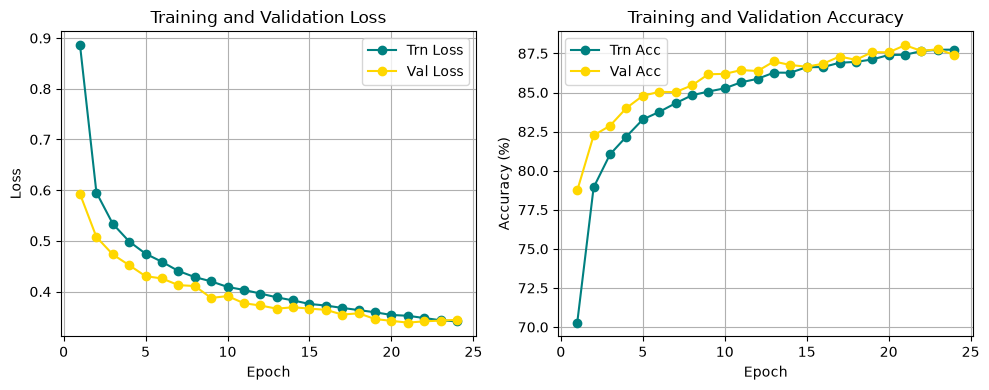

In [2]:
# === Import Required Libraries and Modules === #
import torch # PyTorch library
import torch.nn as nn # PyTorch neural network module
import torch.optim as optim # Optimization algorithms for updating model parameters using gradients
from torchvision import datasets, transforms  # Datasets and image transforms for computer vision tasks
from torch.utils.data import DataLoader, random_split # Tools for loading and splitting datasets
import matplotlib.pyplot as plt # Plotting library for visualization
import os # Operating system interface 

# === Hyperparameters === #
batch_size = 256          # batch size
lr = 0.05                 # learning rate
max_epochs = 60           # maximum number of epochs
max_wait = 3              # Number of epochs without sufficient improvement before early stopping
eps_early = 1e-3 # Minimum decrease in validation loss required to reset the early-stopping counter
dropout_prob = 0.5        # Probability of setting a hidden activation to zero during training
best_path = "best_model_mlp_demo.pth"  # File path for saving the best model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use a GPU if available; otherwise, use the CPU

# === Data Preparation === #
# Define data preprocessing
transform = transforms.Compose([
    transforms.ToTensor(), # Convert images to PyTorch tensors with pixel values in [0, 1]
    transforms.Normalize((0.5,), (0.5,)) # Rescale pixel values to [-1, 1] using a mean and standard deviation of 0.5
])

# Download the data and apply the preprocessing transforms
full_train = datasets.FashionMNIST(root="./data", train=True, transform=transform, download=True) # Load the training dataset and apply the transforms
test_set = datasets.FashionMNIST(root="./data", train=False, transform=transform, download=True) # Load the test dataset and apply the transforms

# Split the full training dataset into training and validation sets in a 4:1 ratio
full_train_size = len(full_train)
train_ratio = 0.8
train_size = int(full_train_size * train_ratio)
val_size = full_train_size - train_size
train_set, val_set = random_split(full_train, [train_size, val_size]) 

print(f"Training samples: {train_size} | Validation samples: {val_size} | Test samples: {len(test_set)}")


# Load mini-batches using DataLoader
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True) # Shuffle the training samples so the model sees a different order each epoch
val_loader   = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_set, batch_size=batch_size, shuffle=False)

# === Define the MLP Model === #
class MLP(nn.Module): # Define the MLP as a subclass of nn.Module
    # Define the layers for the model
    def __init__(self):
        super().__init__() # Initialize the parent nn.Module class

        self.flatten = nn.Flatten() # Flatten each 28 x 28 image into a 1D vector of length 784
        
        self.fc1 = nn.Linear(28*28, 256) # Fully connected layer with 784 inputs and 256 outputs
        self.fc2 = nn.Linear(256, 10) # Map 256 hidden activations to 10 output logits
        
        self.relu = nn.ReLU() # ReLU activation function
        
        self.dropout = nn.Dropout(dropout_prob)   # Apply dropout with the specified probability during training
        

    # Define forward propagation: how data flows through the MLP
    def forward(self, x):
        x = self.flatten(x) # Flatten each input image into a vector
        x = self.fc1(x) # Compute the hidden-layer values: z = W^(1)x + b^(1)
        x = self.relu(x) # Apply the activation function: h = ReLU(z)
        x = self.dropout(x) # Apply dropout regularization
        x = self.fc2(x) # Compute the output logits: W^(2)h + b^(2)
        return x

# Create an MLP instance and move it to the selected device
mlp_model = MLP().to(device)
print(mlp_model)

# === Define the Loss Function and Optimizer === #

# Use cross-entropy loss for multiclass classification
loss_metric = nn.CrossEntropyLoss() 

# Use stochastic gradient descent (SGD) with learning rate lr
# Details about SGD are available at https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html
# Other optimizer parameters can also be configured
optimizer = optim.SGD(mlp_model.parameters(), lr=lr) 

# === Model Training === #
train_loss, val_loss = [], [] # initialize lists to store the training and validation loss for each epoch
train_acc, val_acc = [], [] # initialize lists to store the training and validation accuracy for each epoch

best_val_loss = float("inf") # Initialize the best validation loss to infinity so that any actual loss will be lower
wait = 0 # Initialize the early-stopping counter to zero

for epoch in range(1, max_epochs + 1):
    
    # Training
    mlp_model.train() # Set the model to training mode
    train_running_loss = 0.0 # Accumulate sample-weighted batch losses to compute the average loss
    train_correct = 0 # Number of correctly classified samples
    train_total = 0 # Total number of samples processed so far

    # Process all training mini-batches once per epoch
    for imgs, labels in train_loader: # imgs contains input images (x); labels contains their true classes (y)
        imgs, labels = imgs.to(device), labels.to(device) # Move the data to the same device as the model

        optimizer.zero_grad() # Clear gradients from the previous optimization step
        outputs = mlp_model(imgs) # Run forward propagation to obtain output logits
        loss = loss_metric(outputs, labels) # Compute the loss from the output logits and true class labels
        loss.backward() # Compute gradients through backpropagation
        optimizer.step() # Update model parameters using the computed gradients

        train_running_loss += loss.item()*imgs.size(0) # Multiply the mean batch loss by the batch size and accumulate the total
        preds = outputs.argmax(dim=1) # Select the class with the highest logit for each sample
        train_correct += (preds == labels).sum().item() # Accumulate the number of correctly classified samples
        train_total += labels.size(0) # Accumulate the number of samples processed

    
    train_epoch_loss = train_running_loss / train_total # Divide the accumulated loss by the number of training samples
    train_epoch_acc = 100*train_correct / train_total # Accuracy (%) = 100 x correct predictions / total samples

    # Record training loss and accuracy for plotting
    train_loss.append(train_epoch_loss)
    train_acc.append(train_epoch_acc)


    # Validation
    mlp_model.eval()    # set the model to evaluation mode 
    val_running_loss = 0.0 # Accumulate sample-weighted batch losses to compute the average loss
    val_correct = 0 # Number of correctly classified samples
    val_total = 0 # Total number of samples processed so far
    with torch.no_grad(): # Disable gradient computation for validation
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device) # Move the data to the same device as the model
            outputs = mlp_model(imgs) # Run forward propagation to obtain output logits
            loss = loss_metric(outputs, labels) # Compute the loss from the output logits and true class labels
            val_running_loss += loss.item()*imgs.size(0) # Multiply the mean batch loss by the batch size and accumulate the total
            preds = outputs.argmax(dim=1) # Select the class with the highest logit for each sample
            val_correct += (preds == labels).sum().item() # Accumulate the number of correctly classified samples
            val_total += labels.size(0) # Accumulate the number of samples processed

    val_epoch_loss = val_running_loss / val_total # Divide the accumulated loss by the number of validation samples
    val_epoch_acc = 100.0 * val_correct / val_total # Accuracy (%) = 100 x correct predictions / total samples

    # Record validation loss and accuracy for plotting
    val_loss.append(val_epoch_loss)
    val_acc.append(val_epoch_acc)

    
    print(f"Epoch [{epoch:2d}/{max_epochs}] "
          f"TrainLoss {train_epoch_loss:.4f} TrainAcc {train_epoch_acc:5.2f}% | "
          f"ValLoss {val_epoch_loss:.4f}  ValAcc {val_epoch_acc:5.2f}%")

    # Early stopping
    if val_epoch_loss < best_val_loss - eps_early: # if the validation loss has improved by at least eps_early
        best_val_loss = val_epoch_loss
        wait = 0
        torch.save(mlp_model.state_dict(), best_path) # Save the model's weights and biases to the specified file path
    else:
        wait += 1 # Increment the early-stopping counter if there is no sufficient improvement in validation loss
        if wait >= max_wait: # If the early-stopping counter exceeds the maximum wait time, stop training
            print(f"\nEarly stopping triggered at epoch {epoch+1} because no improvement in validation loss.")
            break

# === Load the Best Model and Evaluate on the Test Set === #
print('\nLoading the best model and evaluating on the test set...')
if os.path.exists(best_path):
    mlp_model.load_state_dict(torch.load(best_path)) # Load the saved weights and biases into the model


# Evaluate on the test set
mlp_model.eval() # Set the model to evaluation mode
test_running_loss = 0.0 # Accumulate sample-weighted batch losses to compute the average loss
test_correct = 0 # Number of correctly classified samples
test_total = 0 # Total number of samples processed so far
with torch.no_grad(): # Disable gradient computation for testing
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device) # Move the data to the same device as the model
        outputs =mlp_model(imgs) # Run forward propagation to obtain output logits
        test_running_loss += loss_metric(outputs, labels).item() # Multiply the mean batch loss by the batch size and accumulate the total
        preds = outputs.argmax(dim=1) # Select the class with the highest logit for each sample
        test_correct += (preds == labels).sum().item() # Accumulate the number of correctly classified samples
        test_total += labels.size(0) # Accumulate the number of samples processed

test_loss = test_running_loss / len(test_loader) # Divide the accumulated loss by the number of test mini-batches to get the average loss
test_acc = 100.0 * test_correct / test_total # Accuracy (%) = 100 x correct predictions / total samples
print(f"TestLoss {test_loss:.4f}  TestAcc {test_acc:.2f}%") 

# === Plot Training History === #
epochs = range(1, len(train_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left subplot: Loss
axes[0].plot(epochs, train_loss, marker='o', color='teal', label="Trn Loss")
axes[0].plot(epochs, val_loss, marker='o', color='gold', label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training and Validation Loss")
axes[0].legend()
axes[0].grid(True)

# Right subplot: Accuracy
axes[1].plot(epochs, train_acc, marker='o', color='teal', label="Trn Acc")
axes[1].plot(epochs, val_acc, marker='o', color='gold', label="Val Acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Training and Validation Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show();


## Damage Level Classification

This example applies an MLP to structural damage assessment. It was contributed by Mohammad Monjurul Karim (SBU CIV Ph.D., 2023).

We develop a binary classification model to identify cracks in inspection images of concrete surfaces. The two classes are crack (Positive) and no crack (Negative).


Using device: cpu
Training samples: 768 | Validation samples: 192 | Test samples: 240
SimpleFCNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2352, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)
Epoch [ 1/100] Trn Loss: 0.8447 Trn Acc: 52.08% | Val Loss: 0.6976 Val Acc: 47.92%
Epoch [ 2/100] Trn Loss: 0.7077 Trn Acc: 52.73% | Val Loss: 0.7091 Val Acc: 52.08%
Epoch [ 3/100] Trn Loss: 0.7066 Trn Acc: 50.52% | Val Loss: 0.6978 Val Acc: 47.92%
Epoch [ 4/100] Trn Loss: 0.6751 Trn Acc: 56.77% | Val Loss: 0.6809 Val Acc: 52.08%
Epoch [ 5/100] Trn Loss: 0.6771 Trn Acc: 52.73% | Val Loss: 0.6826 Val Acc: 48.44%
Epoch [ 6/100] Trn Loss: 0.6678 Trn Acc: 64.97% | Val Loss: 0.6714 Val Acc: 60.94%
Epoch [ 7/100] Trn Loss: 0.6599 Trn Acc: 66.67% | Val Loss: 0.6663 Val Acc: 57.29%
Epoch [ 8/100] Trn Loss: 0.6544 Trn Acc: 68.36% | Val Loss: 0.6572 Val Acc: 68.23%
Epoch [ 9/100] Trn Loss: 0.

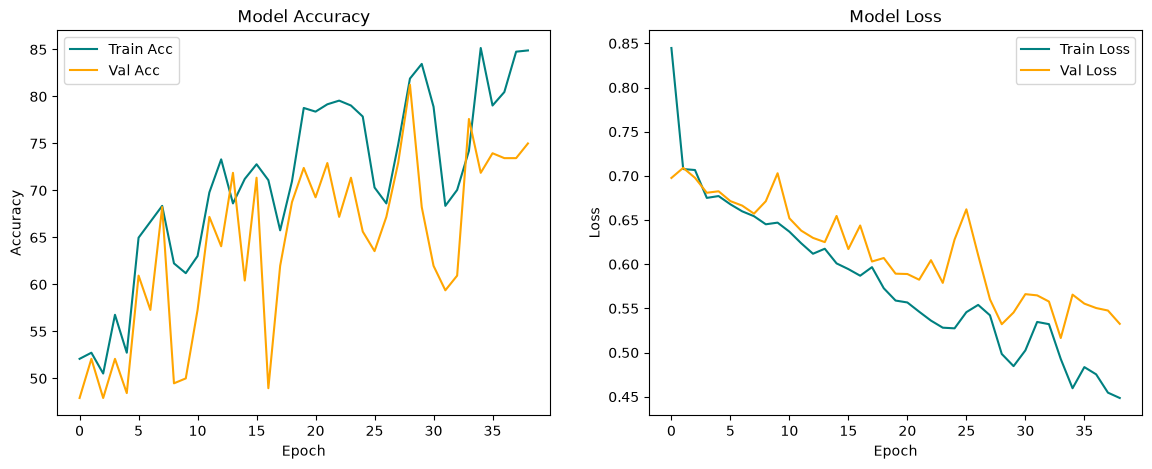

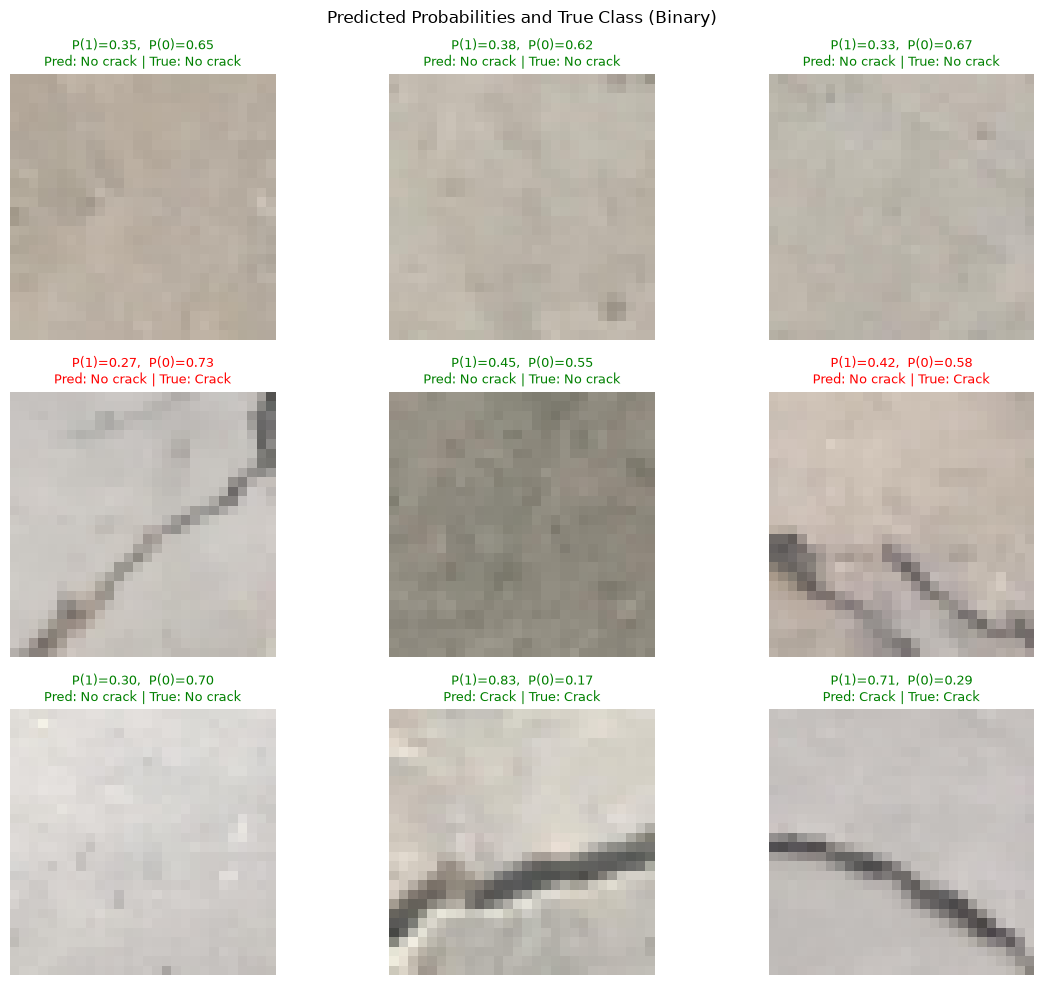

In [3]:
# === Import Required Libraries and Modules === #
import torch
import torch.nn as nn
import torch.optim as optim 
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms 
import matplotlib.pyplot as plt
import time
import random
import os

# === Hyperparameters === #
batch_size = 128
max_epochs = 100
max_wait = 5
eps_early = 1e-8
lr = 0.0005
checkpoint_filepath = 'Data/NNdata/model_best_weights_CrackRec.pth' # Set the path where you want to save the model weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # A CPU is sufficient for this example
print("Using device:", device)

# === Dataset setup === #
# Store the dataset in NNdata using the following folder structure:
# - NNdata
#  |-- train
#     |--Positive
#     |--Negative
#  |-- test
#     |--Positive
#     |--Negative

train_data_dir = 'Data/NNdata/train' 
test_data_dir = 'Data/NNdata/test'
class_names =["No crack", "Crack"]

img_width, img_height = 28, 28

# === Data preprocessing === #

# Preprocess the training data
train_transform = transforms.Compose([
    transforms.Resize((img_width, img_height)), # Resize all images to the specified dimensions
    transforms.RandomHorizontalFlip(),  # Data augmentation: randomly flip images horizontally
    transforms.RandomRotation(10),  # Data augmentation: randomly rotate images by -10 to 10 degrees
    transforms.RandomAffine(degrees=0, shear=10),   # Data augmentation: randomly shear images by -10 to 10 degrees
    transforms.ToTensor() # Convert images to PyTorch tensors
])

# Preprocess the test data
test_transform = transforms.Compose([
    transforms.Resize((img_width, img_height)),
    transforms.ToTensor()
])

# Load the full training dataset and the test dataset
full_train = datasets.ImageFolder(root=train_data_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(root=test_data_dir, transform=test_transform)

# Split the full training dataset into training (80%) and validation (20%) sets
train_size = int(0.8 * len(full_train))
val_size = len(full_train) - train_size
train_dataset, val_dataset = random_split(full_train, [train_size, val_size])

print(f"Training samples: {len(train_dataset)} | Validation samples: {len(val_dataset)} | Test samples: {len(test_dataset)}")

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) 
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# === Define the Network === #
class SimpleFCNN(nn.Module):
    # Define the model architecture
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()       
        self.fc1 = nn.Linear(img_width * img_height * 3, 512) # First fully connected layer: compute 512 intermediate values (z_1)
        self.fc2 = nn.Linear(512, 1) # Second fully connected layer: compute one output value (z_2)
        self.relu = nn.ReLU() # Apply ReLU to z_1 to obtain the hidden activations (h_1)
        self.sigmoid = nn.Sigmoid() # Apply sigmoid to z_2 to obtain a class-1 probability in [0, 1]
        
    # Forward propagation
    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

# Create the model and move it to the selected device
nn_model = SimpleFCNN().to(device)
print(nn_model)

# === Define the Loss Function and Optimizer === #
loss_metric = nn.BCELoss() # Binary cross-entropy loss for binary classification
optimizer = optim.Adam(nn_model.parameters(), lr=lr)

# === Model Training === #

# Initialize variables to track model performance and training progress
best_val_loss = float('inf')
train_loss, val_loss = [], []
train_acc, val_acc = [], []
wait = 0

start_time = time.time()

for epoch in range(max_epochs):
    # Training
    nn_model.train() 
    train_running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.float().unsqueeze(1).to(device) # Convert labels to floats for binary cross-entropy; unsqueeze(1) matches the output shape [batch_size, 1]
        optimizer.zero_grad()
        outputs = nn_model(images)
        loss = loss_metric(outputs, labels)
        loss.backward()
        optimizer.step()

        train_running_loss += loss.item() * images.size(0)
        predicted = (outputs > 0.5).float()
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

    
    train_epoch_loss = train_running_loss / train_total
    train_epoch_acc = 100*train_correct / train_total
    train_loss.append(train_epoch_loss)
    train_acc.append(train_epoch_acc)

    # Validation
    nn_model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
            outputs = nn_model(images)
            loss = loss_metric(outputs, labels)
            val_running_loss += loss.item() * images.size(0)
            predicted = (outputs > 0.5).float()
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_epoch_loss = val_running_loss / val_total
    val_epoch_acc = 100*val_correct / val_total
    val_loss.append(val_epoch_loss)
    val_acc.append(val_epoch_acc)

    print(f"Epoch [{epoch+1:2d}/{max_epochs}] "
          f"Trn Loss: {train_epoch_loss:.4f} Trn Acc: {train_epoch_acc:.2f}% | "
          f"Val Loss: {val_epoch_loss:.4f} Val Acc: {val_epoch_acc:.2f}%")


    # Early stopping
    if val_epoch_loss < best_val_loss - eps_early:
        best_val_loss = val_epoch_loss
        wait = 0
        torch.save(nn_model.state_dict(), checkpoint_filepath)
    else:
        wait += 1
        if wait >= max_wait:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break
   
end_time = time.time()
print('-------------------------------')
print(f"Training time: {end_time - start_time:.2f} seconds")

# === Evaluate Best Model on Test Dataset ===
print('\nLoading the best model and evaluating on the test set...')
nn_model.load_state_dict(torch.load(checkpoint_filepath))
nn_model.eval()

test_running_loss = 0.0
test_correct = 0
test_total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
        outputs = nn_model(images)
        loss = loss_metric(outputs, labels)
        test_running_loss += loss.item() * images.size(0)
        predicted = (outputs > 0.5).float()
        test_correct += (predicted == labels).sum().item()
        test_total += labels.size(0)

test_loss = test_running_loss / test_total
test_acc = 100* test_correct / test_total

print(f"\nBest Model Performance on Test Set:")
print(f"Loss: {test_loss:.4f} | Accuracy: {test_acc:.2f}%")

# === Plot Training History ===
def plot_training(train_acc, val_acc, train_loss, val_loss):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    axs[0].plot(train_acc, 'teal', label='Train Acc')
    axs[0].plot(val_acc, 'orange', label='Val Acc')
    axs[0].set_title('Model Accuracy')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_xlabel('Epoch')
    axs[0].legend(loc='upper left')

    axs[1].plot(train_loss, 'teal', label='Train Loss')
    axs[1].plot(val_loss, 'orange', label='Val Loss')
    axs[1].set_title('Model Loss')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].legend(loc='upper right')

    plt.show()

plot_training(train_acc, val_acc, train_loss, val_loss)


# === Visualize Predictions for 9 Random Test Images ===
nn_model.eval()
all_images, all_labels, all_outputs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = nn_model(images)   # Output shape after sigmoid: [batch_size, 1]
        all_images.append(images.cpu())
        all_labels.append(labels.cpu())
        all_outputs.append(outputs.cpu())  # Outputs are already sigmoid probabilities

all_images = torch.cat(all_images)
all_labels = torch.cat(all_labels)
all_outputs = torch.cat(all_outputs).numpy().flatten()  # Convert to a 1D array

random_indices = random.sample(range(len(all_images)), 9)
fig = plt.figure(figsize=(12,10))
fig.suptitle('Predicted Probabilities and True Class (Binary)')


for k, i in enumerate(random_indices):
    ax = fig.add_subplot(3, 3, k+1)
    img = all_images[i].permute(1,2,0).numpy()
    plt.imshow(img)
    plt.axis('off')

    p = all_outputs[i]            # Probability of class 1
    pred_class = int(p >= 0.5)
    true_class = int(all_labels[i].item())

    # Use green for correct predictions and red for incorrect predictions
    title_color = 'g' if pred_class == true_class else 'r'

    # Format the predicted probabilities for display
    prob_str = f"P(1)={p:.2f},  P(0)={1-p:.2f}"

    result_str = f"Pred: {class_names[pred_class]} | True: {class_names[true_class]}"

    plt.title(f"{prob_str}\n{result_str}", fontsize=9, color=title_color)

plt.tight_layout()
plt.savefig("training_history.png", bbox_inches='tight')
plt.show()

